# Práctica 4 Arizbe Cruz Martínez

**Dataset:** `Big5raw.csv`


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


## 0. Carga de datos

In [3]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

df = pd.read_csv("Big5raw.csv")

print("Dimensiones:", df.shape)

df.head()


Saving Big5raw.csv to Big5raw.csv
Dimensiones: (19726, 57)


,E1,E2,E3,E4,E5,E6,E7,E8,E9,E10,...,O8,O9,O10,race,age,engnat,gender,hand,source,country
0,4,2,5,2,5,1,4,3,5,1,...,2,5,5,3,53.0,1.0,1,1,1,US
1,2,2,3,3,3,3,1,5,1,5,...,1,3,2,13,46.0,1.0,2,1,1,US
2,5,1,1,4,5,1,1,5,5,1,...,5,5,5,1,14.0,2.0,2,1,1,PK
3,2,5,2,4,3,4,3,4,4,5,...,2,5,5,3,19.0,2.0,2,1,1,RO
4,3,1,3,3,3,1,3,1,3,5,...,1,5,3,11,25.0,2.0,2,1,2,US


In [4]:
# Los 50 ítems atributos y las 7 variables demográficas
attr_cols = [c for c in df.columns if c[0] in "ENACO" and c[1:].isdigit()]
demo_cols = ["race", "age", "engnat", "gender", "hand", "source", "country"]

print(f"Ítems de personalidad: {len(attr_cols)}")
print(f"Variables demográficas: {len(demo_cols)}")
df.dtypes.value_counts()


Ítems de personalidad: 50
Variables demográficas: 7


,count
int64,54
float64,2
object,1


## 1. Análisis descriptivo.
4 métricas y 4 gráficos

Basicamente tenemos que evaluar los datos en cuanto a su estructura y contenido antes de limpiarlos.
Calculamos medidas de tendencia central y dispersión (media, desviación estándar,mínimo, máximo) y construimos histogramas, boxplots y una gráfica de dispersión de correlaciones.

In [5]:
# --- Métrica 1 y 2: estadística descriptiva de los ítems de personalidad ---
desc_items = df[attr_cols].describe().T[["mean", "std", "min", "max"]]
print("Resumen estadístico de los 50 ítems (primeros 10):")
desc_items.head(10)


Resumen estadístico de los 50 ítems (primeros 10):


,mean,std,min,max
E1,2.629170,1.233343,0.0,8.0
E2,2.759759,1.313911,0.0,5.0
E3,3.416760,1.236677,0.0,5.0
E4,3.151475,1.223044,0.0,5.0
E5,3.432171,1.282005,0.0,5.0
E6,2.452246,1.241662,0.0,5.0
E7,2.867586,1.431851,0.0,5.0
E8,3.376356,1.266432,0.0,5.0
E9,3.094444,1.396738,0.0,5.0
E10,3.585420,1.305571,0.0,10.0


In [6]:
# --- Métrica 3: conteo de valores faltantes  ---
missing_counts = (df[attr_cols] == 0).sum().sort_values(ascending=False)
print("Top 10 ítems con más valores faltantes (0):")
missing_counts.head(10)


Top 10 ítems con más valores faltantes (0):


,0
E4,3
A9,3
E9,2
A8,2
O10,2
O9,2
C9,2
E10,2
N10,2
E1,1


In [7]:
# --- Métrica 4: distribución de variables demográficas ---
demo_summary = df[["age", "gender", "engnat", "hand"]].describe(include="all")
demo_summary


,age,gender,engnat,hand
count,1.972500e+04,19726.000000,19725.000000,19726.000000
mean,5.075163e+04,1.624556,1.365120,1.131400
std,7.120189e+06,0.884093,0.488895,0.439461
min,1.300000e+01,0.000000,0.000000,0.000000
25%,1.800000e+01,1.000000,1.000000,1.000000
50%,2.200000e+01,2.000000,1.000000,1.000000
75%,3.100000e+01,2.000000,2.000000,1.000000
max,1.000000e+09,99.000000,2.000000,20.000000


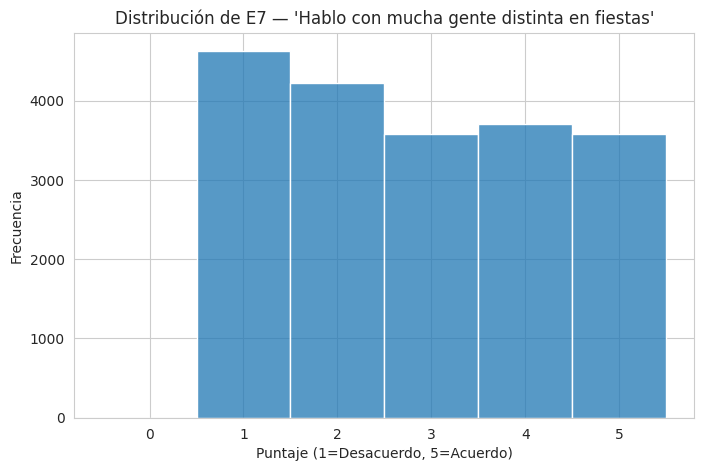

In [8]:
# --- Gráfico 1: Histograma de un ítem representativo (E7) ---
plt.figure()
sns.histplot(df["E7"], bins=5, discrete=True)
plt.title("Distribución de E7 — 'Hablo con mucha gente distinta en fiestas'")
plt.xlabel("Puntaje (1=Desacuerdo, 5=Acuerdo)")
plt.ylabel("Frecuencia")
plt.show()


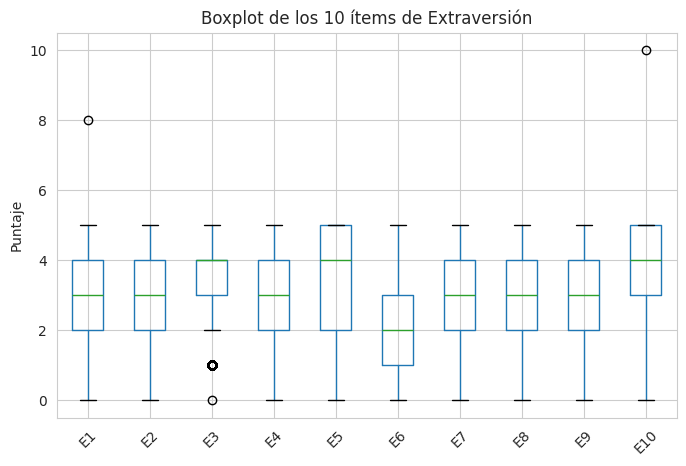

In [9]:
# --- Gráfico 2: Boxplot comparando la dispersión de varios ítems de Extraversión ---
plt.figure()
df[[f"E{i}" for i in range(1, 11)]].boxplot()
plt.title("Boxplot de los 10 ítems de Extraversión")
plt.ylabel("Puntaje")
plt.xticks(rotation=45)
plt.show()


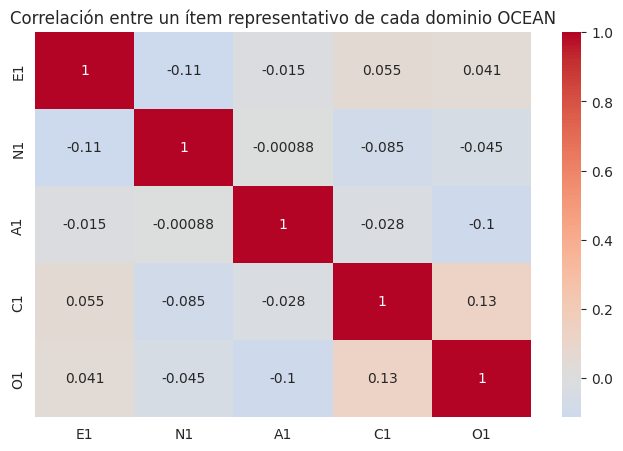

In [10]:
# --- Gráfico 3: Mapa de calor de correlaciones entre los 5 primeros ítems de cada dominio ---
sample_items = ["E1", "N1", "A1", "C1", "O1"]
corr = df[sample_items].corr()
plt.figure()
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlación entre un ítem representativo de cada dominio OCEAN")
plt.show()


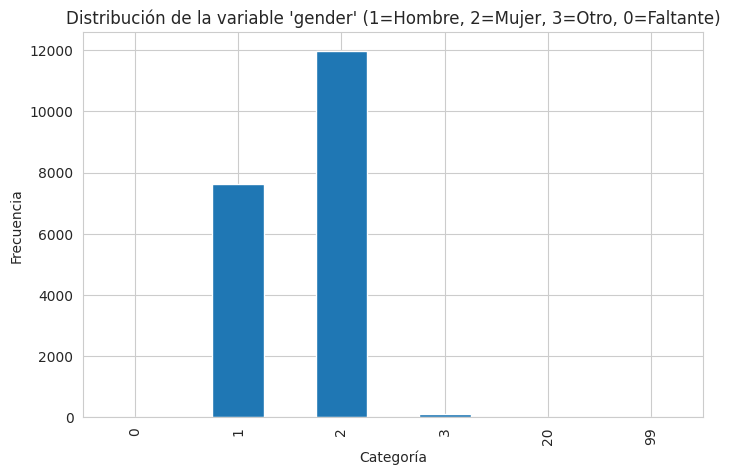

In [11]:
# --- Gráfico 4: Distribución de la variable demográfica 'gender' ---
plt.figure()
df["gender"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribución de la variable 'gender' (1=Hombre, 2=Mujer, 3=Otro, 0=Faltante)")
plt.xlabel("Categoría")
plt.ylabel("Frecuencia")
plt.show()


## 2. Top 3 de variables de personalidad más representativas

**Usando la desviación estándar**

Ya que la varianza es justamente la medida de cuánta información discriminante aporta una variable(un ítem donde casi todos responden lo mismo), no separa bien a las personas, mientras que un ítem con alta varianza sí lo hace. Por eso usamos la desviación estándar como criterio de representatividad.


In [12]:
top3 = df[attr_cols].std().sort_values(ascending=False).head(3)
print("Top 3 variables con mayor desviación estándar (más discriminantes):")
print(top3)


Top 3 variables con mayor desviación estándar (más discriminantes):
E7    1.431851
C6    1.399414
E9    1.396738
dtype: float64



1. **E7** — *"Hablo con mucha gente distinta en las fiestas"*: la respuesta a este ítem
   varía mucho entre personas, separando bien a extrovertidos de introvertidos.
2. **C6** — *"A menudo olvido poner las cosas en su lugar"*: item de Responsabilidad con
   alta dispersión de respuestas.
3. **E9** — *"No me importa ser el centro de atención"*: otro ítem de Extraversión con
   alta varianza.

Las variables con mayor varianza contienen más señal y menos
redundancia es el mismo principio que sustenta el PCA, donde buscamos las
direcciones de máxima varianza en los datos.


## 3. Limpieza de datos

**Indicar cómo y cuántos registros se eliminan en cada caso y el total de registros finales.**

• Eliminar todos los casos con valores faltantes (0) en los atributos.

• Eliminar casos con edades de más de 65

• Eliminar casos con códigos de países inválidos (ISO country code)

• Eliminar cualquier caso con valores faltantes en las variables demográficas


Aplicando los 4 filtros:

In [14]:
n_inicial = len(df)
print(f"Registros iniciales: {n_inicial}")

# --- Eliminar casos con 0 (valor faltante) en cualquier ítem de personalidad ---
step1 = df[~(df[attr_cols] == 0).any(axis=1)].copy()
print(f"Filtro 1 (0 en atributos)      -> quedan: {len(step1):6d} | eliminados: {n_inicial - len(step1)}")


Registros iniciales: 19726
Filtro 1 (0 en atributos)      -> quedan:  19714 | eliminados: 12


In [15]:
# --- Eliminar edades > 65 ---
# Antes de filtrar, revisamos 'age' se capturó como texto libre por si puede tener valores atípicos extremos.
print("Valor máximo de 'age' antes de filtrar:", step1["age"].max())

step2 = step1[step1["age"] <= 65].copy()
print(f"Filtro 2 (age > 65)            -> quedan: {len(step2):6d} | eliminados: {len(step1) - len(step2)}")


Valor máximo de 'age' antes de filtrar: 999999999.0
Filtro 2 (age > 65)            -> quedan:  19497 | eliminados: 217


In [16]:
# --- Eliminar códigos de país inválidos (ISO 3166-1 alpha-2) porque el codebook indica que 'country' es un código ISO. Entonces aqui definimos el conjunto de códigos válidos

iso_codes = set('''AD AE AF AG AI AL AM AO AQ AR AS AT AU AW AX AZ BA BB BD BE BF BG BH BI BJ BL BM BN BO BQ
BR BS BT BV BW BY BZ CA CC CD CF CG CH CI CK CL CM CN CO CR CU CV CW CX CY CZ DE DJ DK DM DO DZ
EC EE EG EH ER ES ET FI FJ FK FM FO FR GA GB GD GE GF GG GH GI GL GM GN GP GQ GR GS GT GU GW GY
HK HM HN HR HT HU ID IE IL IM IN IO IQ IR IS IT JE JM JO JP KE KG KH KI KM KN KP KR KW KY KZ LA
LB LC LI LK LR LS LT LU LV LY MA MC MD ME MF MG MH MK ML MM MN MO MP MQ MR MS MT MU MV MW MX MY
MZ NA NC NE NF NG NI NL NO NP NR NU NZ OM PA PE PF PG PH PK PL PM PN PR PS PT PW PY QA RE RO RS
RU RW SA SB SC SD SE SG SH SI SJ SK SL SM SN SO SR SS ST SV SX SY SZ TC TD TF TG TH TJ TK TL TM
TN TO TR TT TV TW TZ UA UG UM US UY UZ VA VC VE VG VI VN VU WF WS YE YT ZA ZM ZW'''.split())

country_str = step2["country"].apply(lambda x: str(x) if pd.notna(x) else "NAN")
codigos_invalidos = sorted(country_str[~country_str.isin(iso_codes)].unique())
print("Códigos encontrados que NO son ISO válidos:", codigos_invalidos)

step3 = step2[country_str.isin(iso_codes)].copy()
print(f"Filtro 3 (país inválido)       -> quedan: {len(step3):6d} | eliminados: {len(step2) - len(step3)}")


Códigos encontrados que NO son ISO válidos: ['(nu', 'A1', 'A2', 'AP', 'EU', 'MXN', 'NAN', 'USA', 'USS', 'XX']
Filtro 3 (país inválido)       -> quedan:  19057 | eliminados: 440


In [17]:
# --- Eliminar valores faltantes (0 / NaN) en variables demográficas ---
demo_cat = ["race", "age", "engnat", "gender", "hand", "source"]
missing_demo = (step3[demo_cat] == 0).any(axis=1) | step3["country"].isna()

step4 = step3[~missing_demo].copy()
print(f"Filtro 4 (demográficos faltantes) -> quedan: {len(step4):6d} | eliminados: {len(step3) - len(step4)}")

print("\n" + "="*55)
print(f"RESUMEN: {n_inicial} -> {len(step4)} registros finales")
print(f"Total de registros eliminados: {n_inicial - len(step4)} ({(n_inicial-len(step4))/n_inicial:.2%})")
print("="*55)

df_clean = step4.reset_index(drop=True)


Filtro 4 (demográficos faltantes) -> quedan:  18736 | eliminados: 321

RESUMEN: 19726 -> 18736 registros finales
Total de registros eliminados: 990 (5.02%)


**Tabla resumen de limpieza**

| Paso | Filtro aplicado | Registros eliminados | Registros restantes |
|---|---|---:|---:|
| 0 | Dataset original | — | 19,726 |
| 1 | Ceros en ítems de personalidad | 12 | 19,714 |
| 2 | Edad > 65 | 217 | 19,497 |
| 3 | Código de país ISO inválido | 440 | 19,057 |
| 4 | Faltantes en variables demográficas | 321 | 18,736 |
| **Total final** | | **990 eliminados (5.02%)** | **18,736** |

*Aqui como fun fact, los códigos de paises inválidos encontrados incluyen valores corruptos como
`(null`, `USA`, `USS`, `MXN`, `XX`, `A1`, `A2`, `AP`, `EU` ) ninguno es un código ISO3166-1 alpha-2 real de un país, entonces son datos que no se ajustan al formato y datos con valores no permitidos.*


## 4. Análisis de Componentes Principales (PCA)

Sabemos que si varias variables están fuertemente correlacionadas, contienen información redundante y pueden sustituirse por un número menor de componentes sin gran pérdida de información.
Entonces lo aplicamos a los 50 ítems de personalidad para ver si realmente se reducen a las 5 dimensiones OCEAN teóricas o si se necesitan más componentes para capturar el 90% de la varianza.

Primero **estandarizamos** los datos antes de PCA, ya que el algoritmo maximiza varianza.

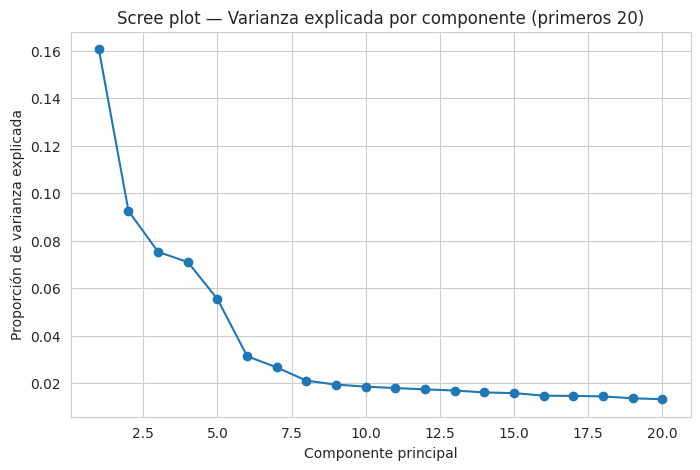

In [18]:
X = df_clean[attr_cols].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
pca.fit(X_scaled)

varianza_explicada = pca.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

# Gráfico de codo
plt.figure()
plt.plot(range(1, 21), varianza_explicada[:20], marker="o")
plt.title("Scree plot — Varianza explicada por componente (primeros 20)")
plt.xlabel("Componente principal")
plt.ylabel("Proporción de varianza explicada")
plt.show()


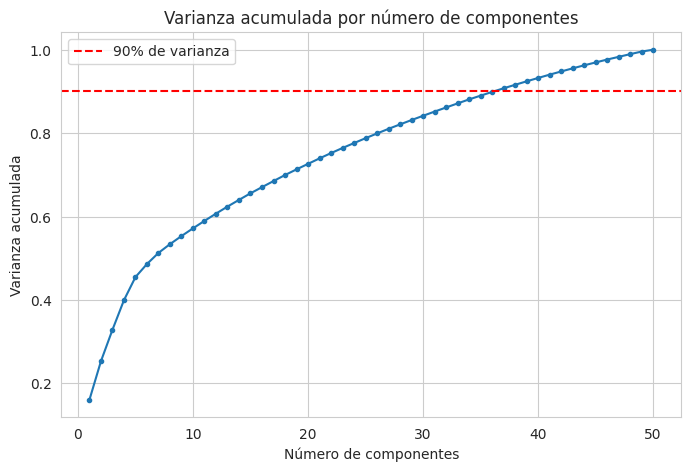

Componentes necesarios para explicar >= 90% de la varianza: 37
Componentes con eigenvalue > 1 (criterio de Kaiser): 8


In [19]:
plt.figure()
plt.plot(range(1, 51), varianza_acumulada, marker=".")
plt.axhline(0.90, color="red", linestyle="--", label="90% de varianza")
plt.title("Varianza acumulada por número de componentes")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza acumulada")
plt.legend()
plt.show()

n_componentes_90 = np.argmax(varianza_acumulada >= 0.90) + 1
print(f"Componentes necesarios para explicar >= 90% de la varianza: {n_componentes_90}")

n_kaiser = (pca.explained_variance_ > 1).sum()
print(f"Componentes con eigenvalue > 1 (criterio de Kaiser): {n_kaiser}")


In [20]:
# Cargas de los primeros 5 componentes para identificar qué variables son representativas de cada componente
loadings = pd.DataFrame(
    pca.components_[:5].T,
    index=attr_cols,
    columns=[f"PC{i+1}" for i in range(5)]
)

for i in range(1, 6):
    top = loadings[f"PC{i}"].abs().sort_values(ascending=False).head(6).index
    print(f"\nVariables más representativas de PC{i}:")
    print(loadings.loc[top, f"PC{i}"].round(3))



Variables más representativas de PC1:
E3     0.251
E5     0.232
E7     0.221
E4    -0.207
E10   -0.202
E6    -0.198
Name: PC1, dtype: float64

Variables más representativas de PC2:
N6    0.253
N8    0.249
N7    0.245
N1    0.228
N3    0.216
A9    0.208
Name: PC2, dtype: float64

Variables más representativas de PC3:
A4    0.249
C9    0.242
C7    0.229
A6    0.226
A9    0.222
C5    0.211
Name: PC3, dtype: float64

Variables más representativas de PC4:
O10    0.331
O1     0.330
O8     0.326
O5     0.299
O2    -0.293
O3     0.291
Name: PC4, dtype: float64

Variables más representativas de PC5:
C9    0.248
C5    0.236
N9    0.226
C7    0.222
C1    0.212
A4   -0.207
Name: PC5, dtype: float64


**Concluimos que para el PCA...**

- Se necesitan **37 componentes** para explicar el 90% de la
  varianza de los 50 ítems originales entonces, **la reducción de variables NO es drástica** si el criterio es 90%.
- Con el criterio de Kaiser solo se retienen **~8 componentes**, y ya con **5 componentes** se alcanza ~45% de la varianza.
- Las cargas de los primeros 5 componentes recuperan casi perfectamente la estructura teórica del Big Five:
  - **PC1** → ítems de Extraversión (E3, E5, E7 positivos; E4, E6, E10 negativos = ítems
    invertidos)
  - **PC2** → ítems de Neuroticismo (N1, N3, N6, N7, N8)
  - **PC3** → mezcla de Amabilidad/Responsabilidad (A4, A6, A9, C5, C7, C9)
  - **PC4** → ítems de Apertura (O1, O5, O8, O10)
  - **PC5** → otra combinación de Responsabilidad/Neuroticismo

**No** es necesario usar los **50 ítems originales**, con retener entre **5 y 8** componentes principales,para reducir  dimensionalidad, aceleramos el clustering y evitamos el problema de la "maldición de la dimensionalidad" en el cálculo de distancias.


## 5. Clustering (K-means para k=2, 3 y 5)

Aplicamos el algoritmo **K-means** que parte de centroides iniciales, asigna
cada tupla al centroide más cercano según **distancia Euclidiana**, recalcula
centroides, y repite hasta que no cambien así minimizando la dispersión intragrupo.

Usamos como entrada los **componentes principales**.


In [21]:
pca8 = PCA(n_components=8, random_state=42)
X_pca8 = pca8.fit_transform(X_scaled)
print(f"Varianza retenida con 8 componentes: {pca8.explained_variance_ratio_.sum():.2%}")


Varianza retenida con 8 componentes: 53.38%


In [22]:
resultados = {}
for k in [2, 3, 5]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca8)
    tamanos = pd.Series(labels).value_counts().sort_index()
    sil = silhouette_score(X_pca8, labels, sample_size=5000, random_state=42)
    resultados[k] = {"labels": labels, "tamanos": tamanos, "silhouette": sil, "inertia": km.inertia_}
    print(f"k={k}  |  tamaños de clúster: {tamanos.to_dict()}  |  "
          f"clúster más pequeño: {tamanos.min()}  |  silhouette: {sil:.4f}")


k=2  |  tamaños de clúster: {0: 9470, 1: 9266}  |  clúster más pequeño: 9266  |  silhouette: 0.1748
k=3  |  tamaños de clúster: {0: 6496, 1: 6520, 2: 5720}  |  clúster más pequeño: 5720  |  silhouette: 0.1296
k=5  |  tamaños de clúster: {0: 2642, 1: 4251, 2: 3574, 3: 4273, 4: 3996}  |  clúster más pequeño: 2642  |  silhouette: 0.1260


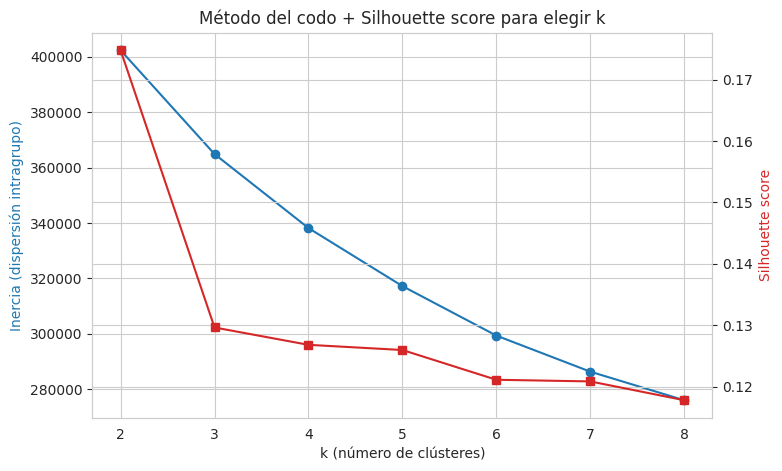

In [23]:
# Método del codo para apoyar la elección de k
inercias = []
sils = []
rango_k = range(2, 9)
for k in rango_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca8)
    inercias.append(km.inertia_)
    sils.append(silhouette_score(X_pca8, labels, sample_size=5000, random_state=42))

fig, ax1 = plt.subplots()
ax1.plot(list(rango_k), inercias, marker="o", color="tab:blue")
ax1.set_xlabel("k (número de clústeres)")
ax1.set_ylabel("Inercia (dispersión intragrupo)", color="tab:blue")

ax2 = ax1.twinx()
ax2.plot(list(rango_k), sils, marker="s", color="tab:red")
ax2.set_ylabel("Silhouette score", color="tab:red")

plt.title("Método del codo + Silhouette score para elegir k")
plt.show()



**¿Qué clúster tiene menos datos?**

En los tres escenarios, el clúster más pequeño aparece siempre en la partición de **k=5** (el más fragmentado, 2,600 registros en el clúster minoritario)

**¿Cuántos clústeres recomiendo? k=2**

- El **silhouette score** es más alto en k=2 (~0.17) y decrece conforme aumenta k (k=3 ≈0.13, k=5 ≈0.13), lo que indica que la separación entre grupos es más clara con menos clústeres.
- La curva del **método del codo** no muestra un quiebre pronunciado, la inercia
  decrece de forma suave y continua, sin un "codo" evidente en k=3 o k=5. Esto es consistente con la naturaleza de los datos porque k-means asume
  clústeres convexos y de tamaño similar, y los rasgos de personalidad son
  dimensiones continuas, no categorías discretas por lo que no debemos esperar clústeres muy bien separados.
- Con k=2 obtenemos la partición más simple e interpretable

## 6. Análisis descriptivo de los clústeres generados (k=3)

Calculamos el promedio de cada uno de los 5 dominios OCEAN
por clúster. Primero recodificamos los ítems redactados en sentido inverso usando `6 - valor`, siguiendo la clave de calificación estándar del cuestionario IPIP-50, antes de promediar.

In [24]:
df_clean["cluster_k3"] = resultados[3]["labels"]

items_invertidos = ["E2","E4","E6","E8","E10","N2","N4","A1","A3","A5","A7","C2","C4","C6","C8","O2","O4","O6"]

df_scored = df_clean.copy()
for it in items_invertidos:
    df_scored[it] = 6 - df_scored[it]

dominios = {
    "Extraversion":    [f"E{i}" for i in range(1, 11)],
    "Neuroticismo":    [f"N{i}" for i in range(1, 11)],
    "Amabilidad":      [f"A{i}" for i in range(1, 11)],
    "Responsabilidad": [f"C{i}" for i in range(1, 11)],
    "Apertura":        [f"O{i}" for i in range(1, 11)],
}
for dom, cols in dominios.items():
    df_scored[dom] = df_scored[cols].mean(axis=1)

perfil = df_scored.groupby("cluster_k3")[list(dominios.keys())].mean().round(2)
tamanios = df_scored["cluster_k3"].value_counts().sort_index()
perfil["n"] = tamanios
perfil


,Extraversion,Neuroticismo,Amabilidad,Responsabilidad,Apertura,n
cluster_k3,,,,,,
0,2.16,3.35,3.32,3.18,3.66,6496
1,3.57,2.32,4.15,3.74,4.05,6520
2,3.34,3.71,4.09,3.07,4.04,5720


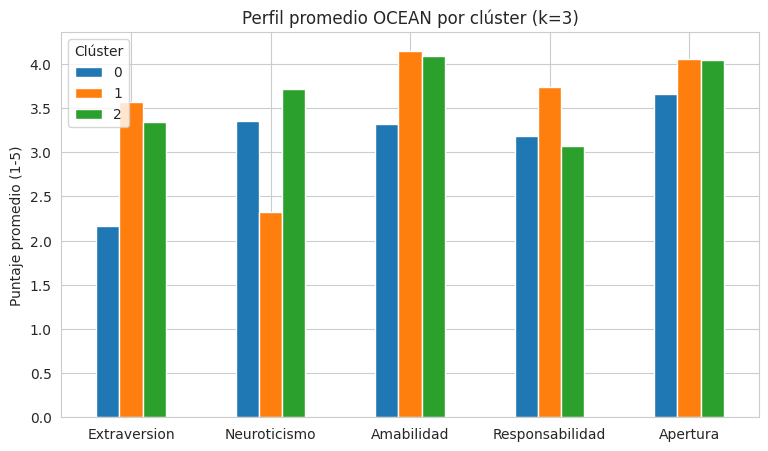

In [25]:
# Gráfico de barras comparando el perfil OCEAN promedio de cada clúster
perfil[list(dominios.keys())].T.plot(kind="bar", figsize=(9, 5))
plt.title("Perfil promedio OCEAN por clúster (k=3)")
plt.ylabel("Puntaje promedio (1-5)")
plt.xticks(rotation=0)
plt.legend(title="Clúster")
plt.show()


Se realizó asi porque de lo contrario el promedio del dominio quedaría distorsionado por ítems que miden en dirección opuesta.


- **Clúster 0** — Extraversión baja (2.2), Neuroticismo alto (3.4): perfil de
  personas **introvertidas y algo ansiosas/inestables**.
- **Clúster 1** — Extraversión alta (3.6), Neuroticismo bajo (2.3), Amabilidad y
  Responsabilidad altas: perfil de personas **extrovertidas, estables y bien
  ajustadas socialmente**.
- **Clúster 2** — Extraversión moderada-alta (3.3) pero Neuroticismo también alto (~3.7), Responsabilidad más baja: perfil de personas **extrovertidas pero
  emocionalmente inestables**.

Los clústeres separan principalmente por **Extraversión y Neuroticismo**, que fueron justamente los dos primeros componentes principales más fuertes.


## Conclusiones:

1. El dataset tenía un 5.02% de registros problemáticos, eliminados en 4 filtros
   secuenciales trazables (990 de 19,726).
2. La varianza de los ítems (E7, C6, E9) es un buen indicador preliminar de qué
   variables son más discriminantes, antes de aplicar técnicas formales como PCA.
3. El PCA confirma que,con solo 5-8 componentes se recupera casi perfectamente la estructura teórica del Big Five.
4. k=2 es la partición más defendible y su interpretación es psicológicamente la más coherente.
